In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import tensorflow as tf
from tensorflow.keras import layers, callbacks
from tensorflow.keras.layers.experimental import preprocessing
from matplotlib import pyplot as plt
from tqdm import tqdm

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/digit-recognizer/sample_submission.csv
/kaggle/input/digit-recognizer/train.csv
/kaggle/input/digit-recognizer/test.csv


## Read data

In [2]:
train = pd.read_csv("../input/digit-recognizer/train.csv")
test = pd.read_csv("../input/digit-recognizer/test.csv")
submission = pd.read_csv("../input/digit-recognizer/sample_submission.csv")

In [3]:
train.shape

(42000, 785)

In [4]:
train.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
X_train = (train.iloc[:,1:].values).astype('float32') # all pixel values
y_train = train.iloc[:,0].values.astype('int32') # only labels i.e targets digits
X_test = test.values.astype('float32')

In [6]:
X_train = X_train.reshape(X_train.shape[0], 28, 28)

In [7]:
X_test = X_test.reshape(X_test.shape[0], 28, 28)

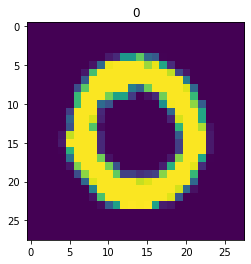

In [8]:
plt.imshow(X_train[1])
plt.title(y_train[1]);

## Tensorflow Keras baseline model

In [9]:
def train_model(model, train_features, train_label, epochs,early_stopping,
                batch_size=None, validation_split=0.1):

    history = model.fit(x=train_features, y=train_label, batch_size=batch_size,
                      epochs=epochs, shuffle=True, 
                      callbacks=[early_stopping],
                      validation_split=validation_split)
    epochs = history.epoch
    hist = pd.DataFrame(history.history)
    return epochs, hist    

In [10]:
def create_nn_model(my_learning_rate):
    model = tf.keras.models.Sequential()
    model.add(tf.keras.layers.Flatten(input_shape=(28, 28)))  
    model.add(tf.keras.layers.Dense(units=256, activation='relu'))
    model.add(tf.keras.layers.Dropout(rate=0.2))
    model.add(layers.BatchNormalization())
    model.add(tf.keras.layers.Dense(units=128, activation='relu'))
    model.add(tf.keras.layers.Dropout(rate=0.2))
    model.add(layers.BatchNormalization())
    model.add(tf.keras.layers.Dense(units=10, activation='softmax'))                          
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=my_learning_rate),
                loss="sparse_categorical_crossentropy",
                metrics=['accuracy'])
    return model    

In [11]:
def plot_curve(epochs, hist, list_of_metrics):
    plt.figure()
    plt.xlabel("Epoch")
    plt.ylabel("Value")
    for m in list_of_metrics:
        x = hist[m]
        plt.plot(epochs[1:], x[1:], label=m)
    plt.legend()
    print("Loaded the plot_curve function.")

In [12]:
learning_rate = 0.001
epochs = 100
batch_size = 4000
validation_split = 0.2

reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2,
                              patience=5, min_lr=0.001)

early_stopping = callbacks.EarlyStopping(
        min_delta=0.001, # minimium amount of change to count as an improvement
        patience=20, # how many epochs to wait before stopping
        restore_best_weights=True,
    )

# Establish the model's topography.
tf_model = create_nn_model(learning_rate)

# Train the model on the normalized training set.
epochs, tf_hist = train_model(tf_model, X_train, y_train, 
                           epochs, early_stopping, batch_size, validation_split)

2022-07-10 15:38:24.980919: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-07-10 15:38:25.093131: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-07-10 15:38:25.093985: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-07-10 15:38:25.095732: I tensorflow/core/platform/cpu_feature_guard.cc:142] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compil

Epoch 1/100
9/9 [==============================] - 2s 50ms/step - loss: 1.4849 - accuracy: 0.5280 - val_loss: 1.1306 - val_accuracy: 0.7769
Epoch 2/100
9/9 [==============================] - 0s 20ms/step - loss: 0.5373 - accuracy: 0.8412 - val_loss: 0.6279 - val_accuracy: 0.8657
Epoch 3/100
9/9 [==============================] - 0s 19ms/step - loss: 0.3827 - accuracy: 0.8892 - val_loss: 0.4313 - val_accuracy: 0.8952
Epoch 4/100
9/9 [==============================] - 0s 14ms/step - loss: 0.3088 - accuracy: 0.9110 - val_loss: 0.3084 - val_accuracy: 0.9167
Epoch 5/100
9/9 [==============================] - 0s 19ms/step - loss: 0.2660 - accuracy: 0.9224 - val_loss: 0.2343 - val_accuracy: 0.9369
Epoch 6/100
9/9 [==============================] - 0s 13ms/step - loss: 0.2298 - accuracy: 0.9340 - val_loss: 0.2017 - val_accuracy: 0.9455
Epoch 7/100
9/9 [==============================] - 0s 19ms/step - loss: 0.2041 - accuracy: 0.9420 - val_loss: 0.1842 - val_accuracy: 0.9479
Epoch 8/100
9/9 [===

In [13]:
tf_model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
flatten (Flatten)            (None, 784)               0         
_________________________________________________________________
dense (Dense)                (None, 256)               200960    
_________________________________________________________________
dropout (Dropout)            (None, 256)               0         
_________________________________________________________________
batch_normalization (BatchNo (None, 256)               1024      
_________________________________________________________________
dense_1 (Dense)              (None, 128)               32896     
_________________________________________________________________
dropout_1 (Dropout)          (None, 128)               0         
_________________________________________________________________
batch_normalization_1 (Batch (None, 128)               5

Loaded the plot_curve function.
 Best validation accuracy :  0.9766666889190674


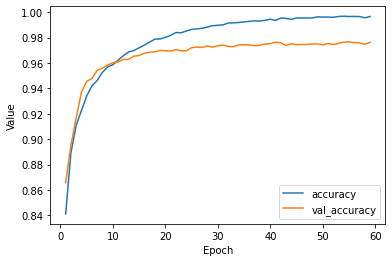

In [14]:
# Plot a graph of the metric vs. epochs.
list_of_metrics_to_plot = ['accuracy', 'val_accuracy']
plot_curve(epochs, tf_hist, list_of_metrics_to_plot)
print(" Best validation accuracy : ", max(tf_hist['val_accuracy']))

### From the below figure, we can see that 0 got miscategorized as 9

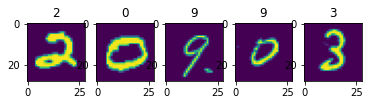

In [15]:
num_rows = 1
num_cols = 5
num_images = num_rows*num_cols
for i in range(num_images):
    plt.subplot(num_rows, num_cols, i+1)
    plt.title(np.argmax(tf_model.predict(X_test)[i], axis=0)) #Predicted
    plt.imshow(X_test[i]) #Viz

In [16]:
test_results = tf_model.predict(X_test)

In [17]:
submission['Label'] = [np.argmax(test_results[i], axis=0) for i in tqdm(range(len(X_test)))]

100%|██████████| 28000/28000 [00:00<00:00, 203208.18it/s]


In [18]:
submission

,ImageId,Label
0,1,2
1,2,0
2,3,9
3,4,9
4,5,3
...,...,...
27995,27996,9
27996,27997,7
27997,27998,3
27998,27999,9


In [19]:
submission.to_csv('submission_tf_baseline.csv', index=False)

## CNN model

As input, a CNN takes tensors of shape (image_height, image_width, color_channels), so added gray channel to the input

In [20]:
def create_cnn_tf_model(my_learning_rate):
    
    model = tf.keras.Sequential()
    model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same', kernel_initializer='he_uniform', input_shape=(28, 28, 1)))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.25))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same', kernel_initializer='he_uniform', input_shape=(28, 28, 1)))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.25))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same', kernel_initializer='he_uniform', input_shape=(28, 28, 1)))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.25))
    model.add(layers.BatchNormalization())
    model.add(layers.Flatten())
    model.add(layers.Dense(64, activation='relu', kernel_initializer='he_uniform'))
    model.add(layers.Dense(10, activation='softmax'))
    
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=my_learning_rate),
                loss="sparse_categorical_crossentropy",
                metrics=['accuracy'])
    return model    

In [21]:
X_train = X_train.reshape(-1,28,28,1) #X_train = np.expand_dims(X_train, -1)
X_test = X_test.reshape(-1,28,28,1)

In [22]:
X_train.shape

(42000, 28, 28, 1)

In [23]:
learning_rate = 0.01
epochs = 100
batch_size = 4000
validation_split = 0.2

early_stopping = callbacks.EarlyStopping(
        min_delta=0.001, # minimium amount of change to count as an improvement
        patience=20, # how many epochs to wait before stopping
        restore_best_weights=True,
    )

# Establish the model's topography.
cnn_tf_model = create_cnn_tf_model(learning_rate)

# Train the model on the normalized training set.
cnn_epochs, cnn_tf_hist = train_model(cnn_tf_model, X_train, y_train, 
                           epochs, early_stopping, batch_size, validation_split)

Epoch 1/100


2022-07-10 15:38:53.119503: I tensorflow/stream_executor/cuda/cuda_dnn.cc:369] Loaded cuDNN version 8005


9/9 [==============================] - 9s 134ms/step - loss: 1.6892 - accuracy: 0.4703 - val_loss: 154.2065 - val_accuracy: 0.2396
Epoch 2/100
9/9 [==============================] - 1s 72ms/step - loss: 0.4091 - accuracy: 0.8737 - val_loss: 46.8126 - val_accuracy: 0.5963
Epoch 3/100
9/9 [==============================] - 1s 72ms/step - loss: 0.2267 - accuracy: 0.9343 - val_loss: 18.1746 - val_accuracy: 0.7114
Epoch 4/100
9/9 [==============================] - 1s 72ms/step - loss: 0.1512 - accuracy: 0.9536 - val_loss: 7.7952 - val_accuracy: 0.7751
Epoch 5/100
9/9 [==============================] - 1s 73ms/step - loss: 0.1163 - accuracy: 0.9629 - val_loss: 3.7190 - val_accuracy: 0.8076
Epoch 6/100
9/9 [==============================] - 1s 73ms/step - loss: 0.0909 - accuracy: 0.9701 - val_loss: 1.7843 - val_accuracy: 0.8492
Epoch 7/100
9/9 [==============================] - 1s 73ms/step - loss: 0.0811 - accuracy: 0.9752 - val_loss: 0.9973 - val_accuracy: 0.8751
Epoch 8/100
9/9 [==========

Loaded the plot_curve function.
 Best validation accuracy :  0.991428554058075


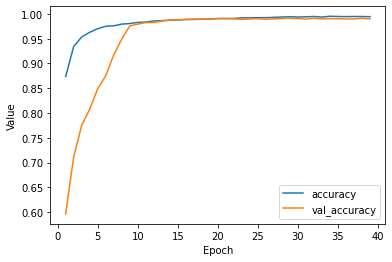

In [24]:
# Plot a graph of the metric vs. epochs.
list_of_metrics_to_plot = ['accuracy', 'val_accuracy']
plot_curve(cnn_epochs, cnn_tf_hist, list_of_metrics_to_plot)
print(" Best validation accuracy : ", max(cnn_tf_hist['val_accuracy']))

### From the below figure we can see that 0 now got correctly categorized as 0

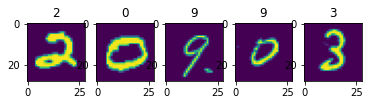

In [25]:
num_rows = 1
num_cols = 5
num_images = num_rows*num_cols
for i in range(num_images):
    plt.subplot(num_rows, num_cols, i+1)
    plt.title(np.argmax(cnn_tf_model.predict(X_test)[i], axis=0)) #Predicted
    plt.imshow(X_test[i]) #Viz

In [26]:
test_results = cnn_tf_model.predict(X_test)

In [27]:
submission['Label'] = [np.argmax(test_results[i], axis=0) for i in tqdm(range(len(X_test)))]

100%|██████████| 28000/28000 [00:00<00:00, 301437.91it/s]


In [28]:
submission.to_csv('submission_tf_cnn.csv', index=False)

## Why did CNN perform better than the MLP? 

### MLP best validation accuracy was 0.975 vs CNN with 0.993

MLP is now deemed insufficient for modern advanced computer vision tasks. MLP has the characteristic of fully connected layers, where each perceptron is connected with every other perceptron. The disadvantage is that the number of total parameters can grow to very high (number of perceptron in layer 1 multiplied by # of p in layer 2 multiplied by # of p in layer 3…). This is inefficient because there is redundancy in such high dimensions. Another disadvantage is that it disregards spatial information. It takes flattened vectors as inputs. This is why we saw 0 being miscategorized as 9.

## CNN with transfer learning from Resnet50

Acknowledgement : https://www.kaggle.com/code/namansood/resnet50-training-on-mnist-transfer-learning

### What is Resnet50

ResNet-50 is a convolutional neural network that is 50 layers deep. You can load a pretrained version of the network trained on more than a million images from the ImageNet database [1]. The pretrained network can classify images into 1000 object categories, such as keyboard, mouse, pencil, and many animals. As a result, the network has learned rich feature representations for a wide range of images. The network has an image input size of 224-by-224

### Channel stacking
We will proceed to stack the data along the last dimension. This will result in an artificially created 3-channeled image (RGB). As most of the pre-trained models work on RGB images, we need to convert ours in the same format as well

In [29]:
X_train = (train.iloc[:,1:].values).astype('float32') # all pixel values
y_train = train.iloc[:,0].values.astype('int32') # only labels i.e targets digits
X_test = test.values.astype('float32')

In [30]:
X_train = X_train.reshape(X_train.shape[0], 28, 28)
X_test = X_test.reshape(X_test.shape[0], 28, 28)

In [31]:
X_train.shape

(42000, 28, 28)

In [32]:
X_train = np.stack((X_train,)*3, axis=-1)
X_test = np.stack((X_test,)*3, axis=-1)

In [33]:
X_train.shape

(42000, 28, 28, 3)

In [34]:
from tensorflow.keras.applications.resnet50 import ResNet50

def create_cnn_resnet50_tf_model(my_learning_rate):
    model = tf.keras.Sequential()
    model.add(ResNet50(include_top = False, pooling = 'max', weights = 'imagenet'))
    model.add(layers.Dense(10, activation = 'softmax'))
    model.layers[0].trainable = False
    
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=my_learning_rate),
                loss="sparse_categorical_crossentropy",
                metrics=['accuracy'])
    return model 

In [35]:
learning_rate = 0.01
epochs = 100
batch_size = 4000
validation_split = 0.2

early_stopping = callbacks.EarlyStopping(
        min_delta=0.001, # minimium amount of change to count as an improvement
        patience=20, # how many epochs to wait before stopping
        restore_best_weights=True,
    )

# Establish the model's topography.
cnn_resnet50_tf_model = create_cnn_resnet50_tf_model(learning_rate)

# Train the model on the normalized training set.
cnn_resnet50_epochs, cnn_resnet50_tf_hist = train_model(cnn_resnet50_tf_model, X_train, y_train, 
                           epochs, early_stopping, batch_size, validation_split)

94781440/94765736 [==============================] - 1s 0us/step
Epoch 1/100
9/9 [==============================] - 7s 494ms/step - loss: 11.9160 - accuracy: 0.2452 - val_loss: 6.6760 - val_accuracy: 0.3762
Epoch 2/100
9/9 [==============================] - 2s 246ms/step - loss: 4.7260 - accuracy: 0.4855 - val_loss: 2.8897 - val_accuracy: 0.6537
Epoch 3/100
9/9 [==============================] - 2s 248ms/step - loss: 2.2056 - accuracy: 0.7059 - val_loss: 1.3949 - val_accuracy: 0.7342
Epoch 4/100
9/9 [==============================] - 2s 254ms/step - loss: 1.2411 - accuracy: 0.7611 - val_loss: 0.9114 - val_accuracy: 0.8277
Epoch 5/100
9/9 [==============================] - 2s 245ms/step - loss: 0.8262 - accuracy: 0.8379 - val_loss: 0.6549 - val_accuracy: 0.8571
Epoch 6/100
9/9 [==============================] - 2s 247ms/step - loss: 0.6196 - accuracy: 0.8610 - val_loss: 0.5257 - val_accuracy: 0.8793
Epoch 7/100
9/9 [==============================] - 2s 248ms/step - loss: 0.4935 - accura

Loaded the plot_curve function.
 Best validation accuracy :  0.9579761624336243


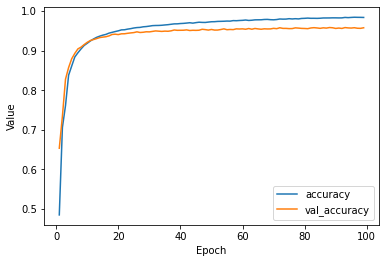

In [36]:
# Plot a graph of the metric vs. epochs.
list_of_metrics_to_plot = ['accuracy', 'val_accuracy']
plot_curve(cnn_resnet50_epochs, cnn_resnet50_tf_hist, list_of_metrics_to_plot)
print(" Best validation accuracy : ", max(cnn_resnet50_tf_hist['val_accuracy']))

### From the below figure we can see that 0 now got miscategorized as 2 instead

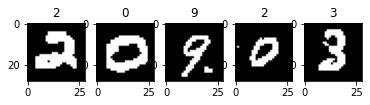

In [37]:
num_rows = 1
num_cols = 5
num_images = num_rows*num_cols
for i in range(num_images):
    plt.subplot(num_rows, num_cols, i+1)
    plt.title(np.argmax(cnn_resnet50_tf_model.predict(X_test)[i], axis=0)) #Predicted
    plt.imshow(X_test[i]) #Viz

In [38]:
test_results = cnn_resnet50_tf_model.predict(X_test)

In [39]:
submission['Label'] = [np.argmax(test_results[i], axis=0) for i in tqdm(range(len(X_test)))]

100%|██████████| 28000/28000 [00:00<00:00, 244023.61it/s]


In [40]:
submission.to_csv('submission_tf_resnet50.csv', index=False)

## Best model so far seems to be the CNN model

Next steps to try : data augmentation and other transfer learning architectures with the input shape changed

https://www.kaggle.com/code/saumandas/intro-to-transfer-learning-with-mnist/notebook

https://www.kaggle.com/code/donatastamosauskas/using-resnet-for-mnist/notebook

https://www.kaggle.com/code/aymanlafaz/mnist-resnet50-transfer-learning/notebook